In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm                import SVC
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.metrics            import (classification_report, roc_auc_score,
                                         ConfusionMatrixDisplay, RocCurveDisplay,
                                         precision_recall_curve, average_precision_score)
from sklearn.pipeline           import Pipeline
from sklearn.model_selection    import GridSearchCV
from xgboost                    import XGBClassifier
import shap, joblib

print("All imports successful — ready to build!")

All imports successful — ready to build!


Dataset shape: (12330, 18)

Data types:
 Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Missing values:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month  

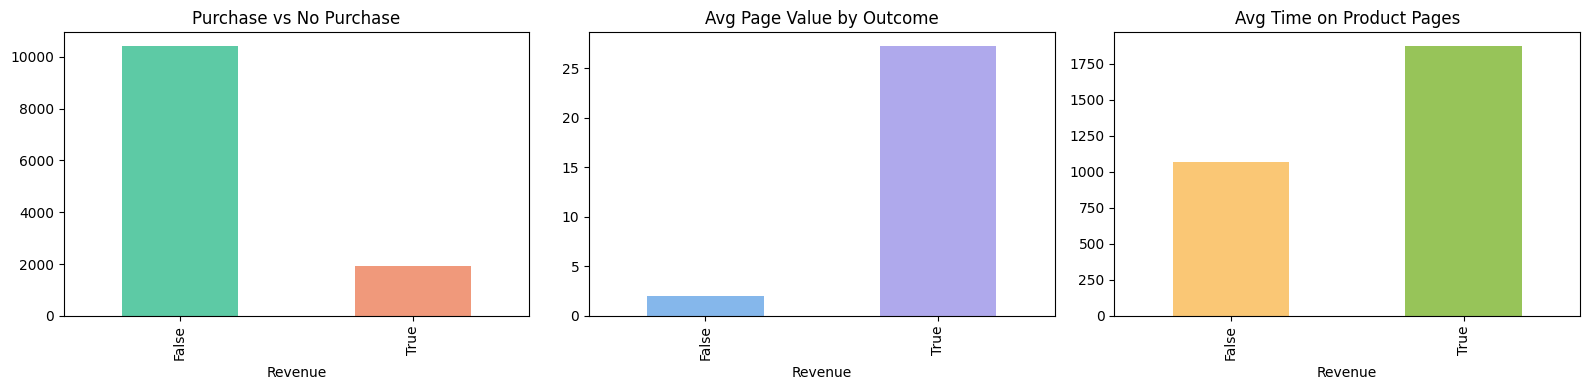

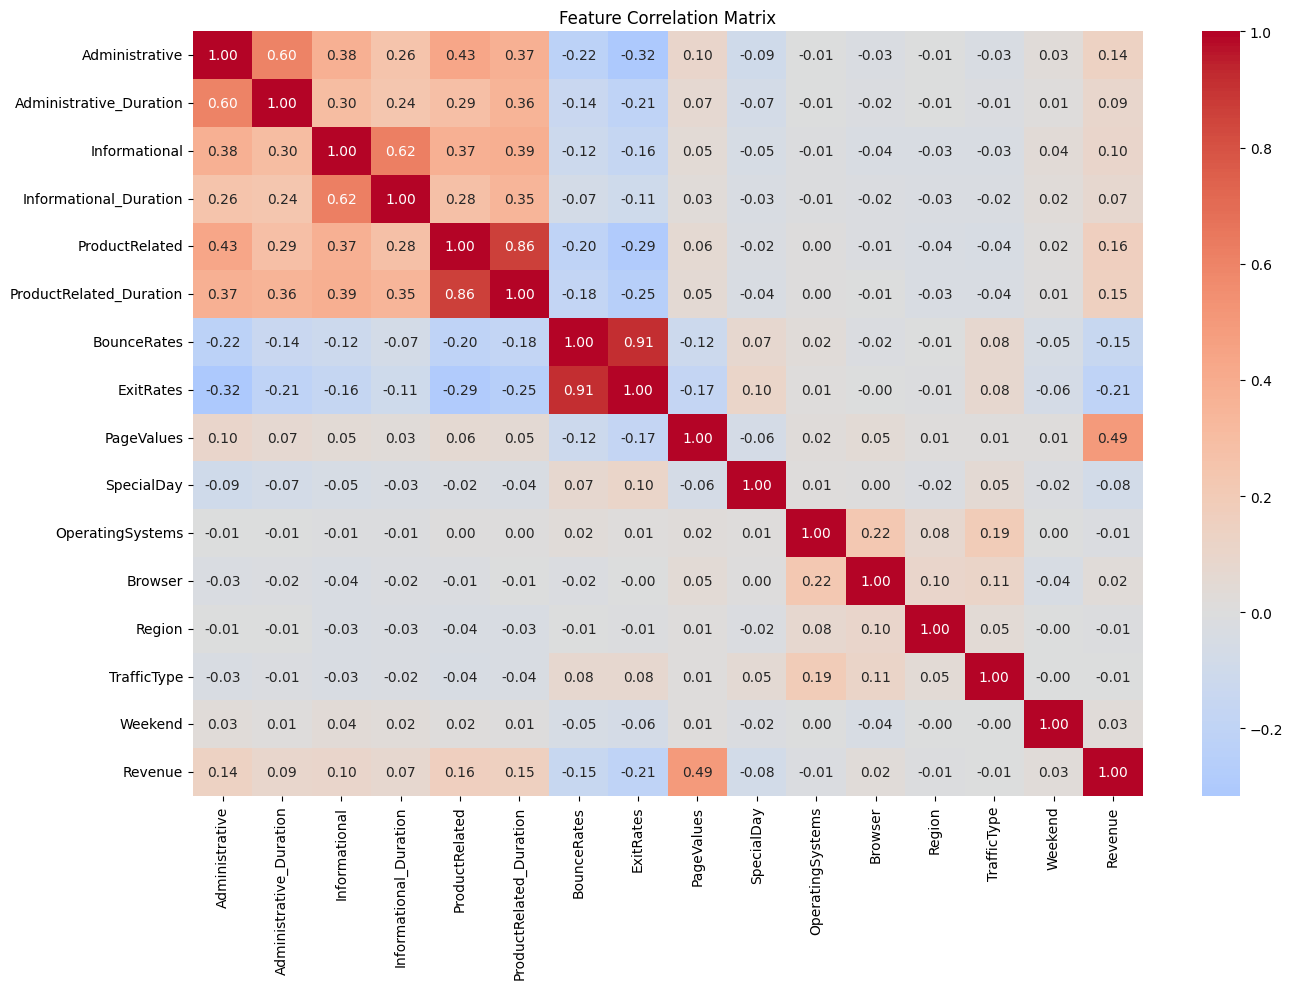

In [3]:
df = pd.read_csv('online_shoppers_intention.csv')

print("Dataset shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass balance:")
print(df['Revenue'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['Revenue'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#5DCAA5','#F0997B'], title='Purchase vs No Purchase')

df.groupby('Revenue')['PageValues'].mean().plot(kind='bar', ax=axes[1],
    color=['#85B7EB','#AFA9EC'], title='Avg Page Value by Outcome')

df.groupby('Revenue')['ProductRelated_Duration'].mean().plot(kind='bar', ax=axes[2],
    color=['#FAC775','#97C459'], title='Avg Time on Product Pages')

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [4]:
le = LabelEncoder()
df['Month']       = le.fit_transform(df['Month'])
df['VisitorType'] = le.fit_transform(df['VisitorType'])
df['Weekend']     = df['Weekend'].astype(int)
df['Revenue']     = df['Revenue'].astype(int)

# --- 11 engineered features (explain each in interviews!) ---

# 1. Total pages visited across all categories
df['total_pages'] = (df['Administrative'] +
                     df['Informational'] +
                     df['ProductRelated'])

# 2. Total time spent on site (seconds)
df['total_duration'] = (df['Administrative_Duration'] +
                        df['Informational_Duration'] +
                        df['ProductRelated_Duration'])

# 3. Bounce vs exit difference — negative means more exits (bad sign)
df['bounce_exit_diff'] = df['BounceRates'] - df['ExitRates']

# 4. Engagement flag — did user spend above-median time?
df['is_engaged'] = (df['total_duration'] > df['total_duration'].median()).astype(int)

# 5. Page value per product page visited
df['value_per_page'] = df['PageValues'] / (df['ProductRelated'] + 1)

# 6. Product page ratio — what fraction of pages were product pages?
df['product_page_ratio'] = df['ProductRelated'] / (df['total_pages'] + 1)

# 7. High page value flag (top 25% = likely buyer)
df['high_value_session'] = (df['PageValues'] > df['PageValues'].quantile(0.75)).astype(int)

# 8. Duration per page — avg time per page visited
df['duration_per_page'] = df['total_duration'] / (df['total_pages'] + 1)

# 9. Is a returning visitor? (VisitorType was label-encoded: check original)
df['is_returning'] = (df['VisitorType'] == 1).astype(int)

# 10. Informational content ratio
df['info_ratio'] = df['Informational'] / (df['total_pages'] + 1)

# 11. Weekend + special day interaction
df['weekend_special'] = df['Weekend'] * df['SpecialDay']

X = df.drop('Revenue', axis=1)
y = df['Revenue']
print(f"Total features: {X.shape[1]}")
print("Feature names:", list(X.columns))

Total features: 28
Feature names: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'total_pages', 'total_duration', 'bounce_exit_diff', 'is_engaged', 'value_per_page', 'product_page_ratio', 'high_value_session', 'duration_per_page', 'is_returning', 'info_ratio', 'weekend_special']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Calculate class weight ratio (replaces SMOTE — no extra install)
spw = round((y_train == 0).sum() / (y_train == 1).sum(), 2)

print(f"spw = {spw}")
print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Class ratio (0:1): {spw} — used as scale_pos_weight in XGBoost")
print(f"Positive class in train: {y_train.mean()*100:.1f}%")

spw = 5.46
Train size : (9864, 28)
Test size  : (2466, 28)
Class ratio (0:1): 5.46 — used as scale_pos_weight in XGBoost
Positive class in train: 15.5%


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, C=0.1),

    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=6, random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        max_depth=10, random_state=42, n_jobs=-1),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=5, random_state=42),

    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=6, scale_pos_weight=spw,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1),

    'SVM': SVC(
        kernel='rbf', class_weight='balanced',
        C=1.0, probability=True, random_state=42),

    'KNN': KNeighborsClassifier(
        n_neighbors=7, weights='distance', n_jobs=-1),
}

print(f"{'Algorithm':<22} {'F1':>6} {'AUC':>6} {'Acc':>6}")
print("-" * 45)
results = {}
for name, m in models.items():
    f1  = cross_val_score(m, X_train_s, y_train, cv=cv, scoring='f1').mean()
    auc = cross_val_score(m, X_train_s, y_train, cv=cv, scoring='roc_auc').mean()
    acc = cross_val_score(m, X_train_s, y_train, cv=cv, scoring='accuracy').mean()
    results[name] = {'F1': f1, 'AUC': auc, 'Acc': acc}
    print(f"{name:<22} {f1:.3f}  {auc:.3f}  {acc:.3f}")

best_name = max(results, key=lambda x: results[x]['F1'])
print(f"\nBest model: {best_name}")

Algorithm                  F1    AUC    Acc
---------------------------------------------
Logistic Regression    0.666  0.908  0.874
Decision Tree          0.636  0.905  0.852
Random Forest          0.678  0.928  0.885
Gradient Boosting      0.641  0.930  0.899
XGBoost                0.669  0.927  0.885
SVM                    0.664  0.900  0.871
KNN                    0.606  0.874  0.890

Best model: Random Forest


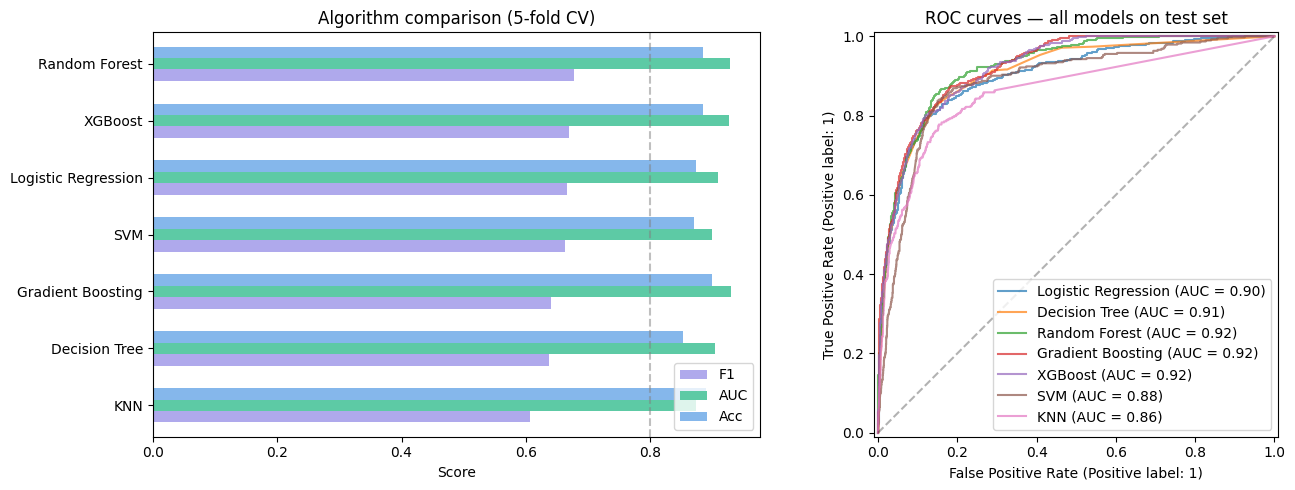

In [7]:
res_df = pd.DataFrame(results).T.sort_values('F1', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_df[['F1','AUC','Acc']].plot(kind='barh', ax=axes[0],
    color=['#AFA9EC','#5DCAA5','#85B7EB'], width=0.6)
axes[0].set_title('Algorithm comparison (5-fold CV)')
axes[0].set_xlabel('Score')
axes[0].axvline(0.8, color='gray', linestyle='--', alpha=0.5)

# ROC curves for all models on test set
for name, m in models.items():
    m.fit(X_train_s, y_train)
    RocCurveDisplay.from_estimator(m, X_test_s, y_test,
        ax=axes[1], name=name, alpha=0.7)
axes[1].set_title('ROC curves — all models on test set')
axes[1].plot([0,1],[0,1],'k--', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
param_grid = {
    'n_estimators'  : [200, 300, 400],
    'max_depth'     : [4, 6, 8],
    'learning_rate' : [0.01, 0.05, 0.1],
    'subsample'     : [0.8, 1.0],
}

xgb_base = XGBClassifier(
    scale_pos_weight=spw, use_label_encoder=False,
    eval_metric='logloss', random_state=42, n_jobs=-1)

grid = GridSearchCV(xgb_base, param_grid, cv=3,
                    scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train_s, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV F1 : {grid.best_score_:.3f}")
best_model = grid.best_estimator_

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best params: {'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 400, 'subsample': 0.8}
Best CV F1 : 0.680


CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Purchase       0.95      0.90      0.93      2084
    Purchase       0.58      0.76      0.66       382

    accuracy                           0.88      2466
   macro avg       0.77      0.83      0.79      2466
weighted avg       0.90      0.88      0.88      2466

AUC-ROC : 0.9280
Avg Prec: 0.7366


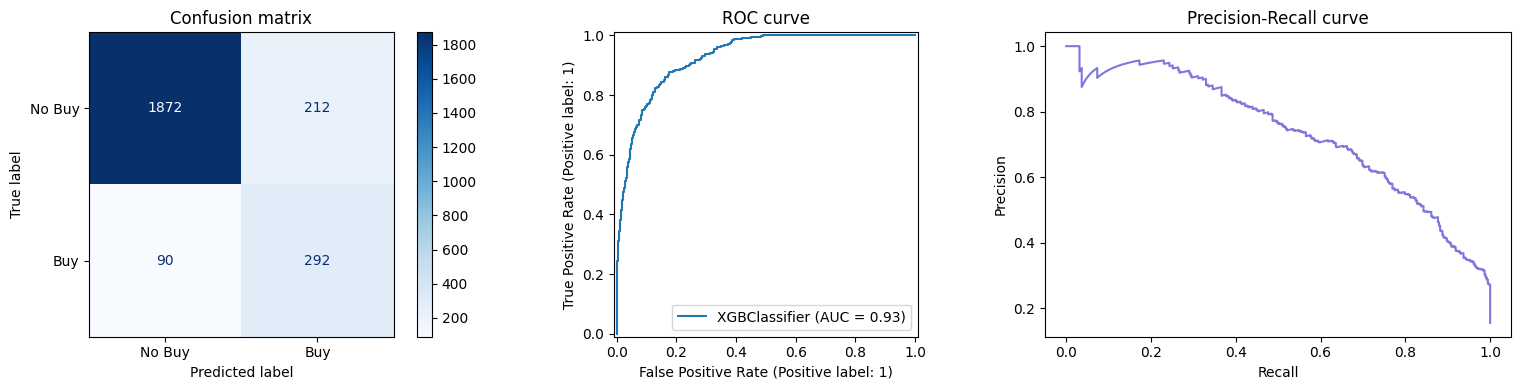

In [9]:
y_pred = best_model.predict(X_test_s)
y_prob = best_model.predict_proba(X_test_s)[:, 1]

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['No Purchase', 'Purchase']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Avg Prec: {average_precision_score(y_test, y_prob):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No Buy','Buy'],
    cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion matrix')

RocCurveDisplay.from_estimator(best_model, X_test_s, y_test, ax=axes[1])
axes[1].set_title('ROC curve')

prec, rec, thresh = precision_recall_curve(y_test, y_prob)
axes[2].plot(rec, prec, color='#7F77DD')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall curve')

plt.tight_layout()
plt.show()

 99%|===================| 2452/2466 [01:54<00:00]        

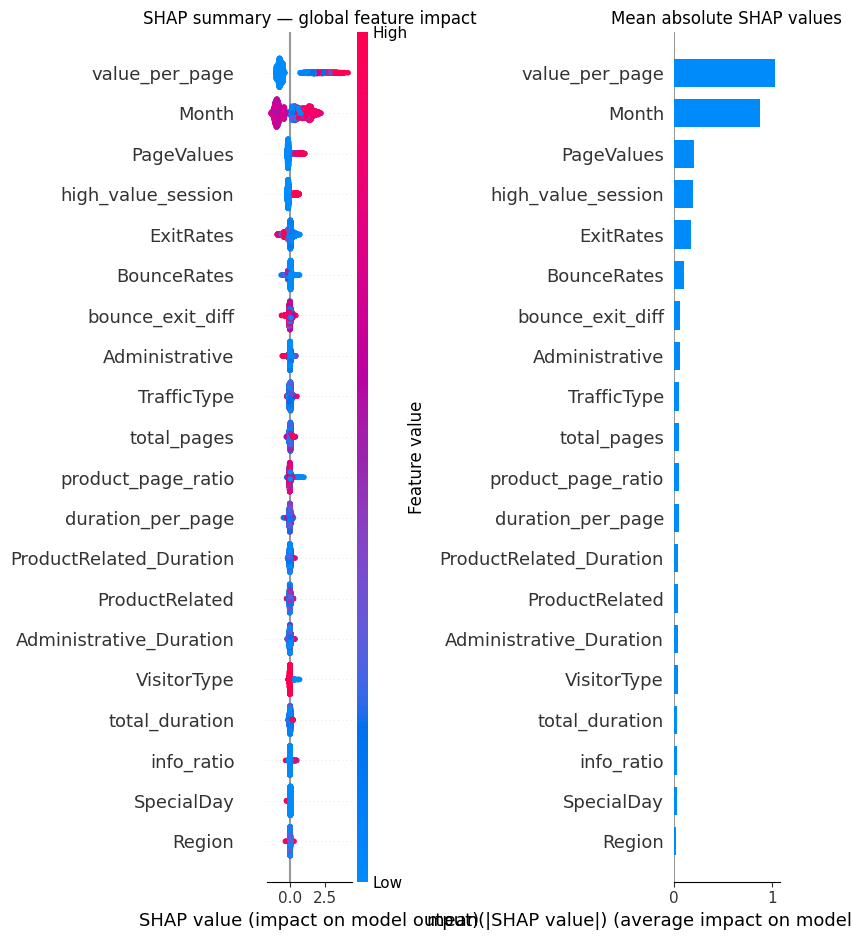

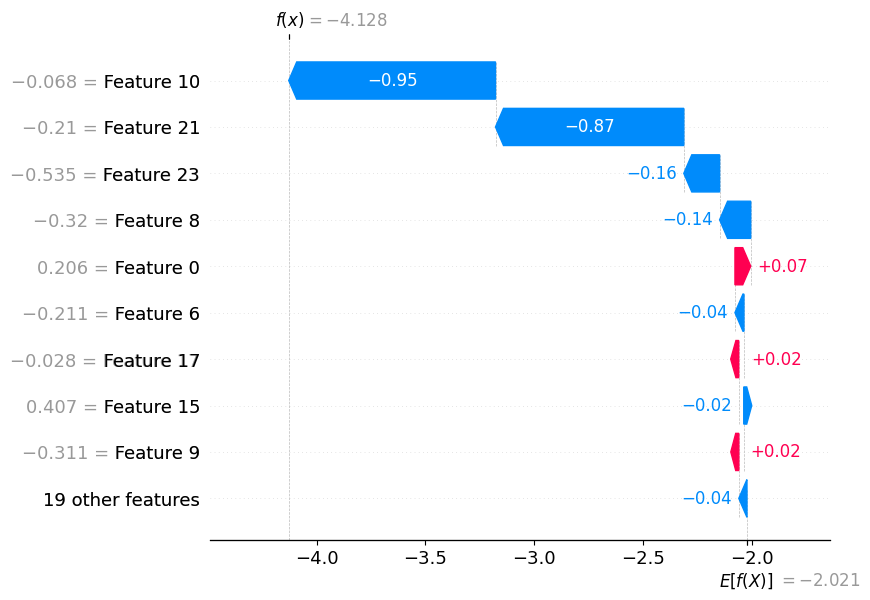


Actual: No Purchase
Predicted prob: 0.016


In [10]:
explainer  = shap.Explainer(best_model, X_train_s)
shap_vals  = explainer(X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_vals, X_test,
    feature_names=X.columns, show=False)
axes[0].set_title('SHAP summary — global feature impact')

plt.sca(axes[1])
shap.summary_plot(shap_vals, X_test,
    feature_names=X.columns, plot_type='bar', show=False)
axes[1].set_title('Mean absolute SHAP values')

plt.tight_layout()
plt.show()

# Explain a single prediction (great for interviews!)
idx = 5
shap.waterfall_plot(shap_vals[idx])
print(f"\nActual: {'Purchase' if y_test.iloc[idx]==1 else 'No Purchase'}")
print(f"Predicted prob: {y_prob[idx]:.3f}")

In [11]:
final_pipeline = Pipeline([
    ('scaler', scaler),
    ('model',  best_model)
])

joblib.dump(final_pipeline, 'ecommerce_model_pipeline.pkl')
print("Pipeline saved!")

# Quick test — load and predict
loaded = joblib.load('ecommerce_model_pipeline.pkl')
sample = X_test.iloc[:3]
preds  = loaded.predict(sample)
probs  = loaded.predict_proba(sample)[:, 1]
for i, (p, prob) in enumerate(zip(preds, probs)):
    label = 'Will BUY' if p == 1 else 'Will NOT buy'
    print(f"Customer {i+1}: {label}  (confidence: {prob*100:.1f}%)")

Pipeline saved!
Customer 1: Will NOT buy  (confidence: 1.1%)
Customer 2: Will NOT buy  (confidence: 9.3%)
Customer 3: Will BUY  (confidence: 93.2%)


In [16]:
import streamlit as st
import joblib, numpy as np, pandas as pd

pipeline = joblib.load('ecommerce_model_pipeline.pkl')

st.set_page_config(page_title="Smart Shopper Predictor", page_icon="🛒", layout="wide")
st.title("E-Commerce Purchase Intent Predictor")
st.caption("Predict whether a visitor will make a purchase — powered by XGBoost")

col1, col2, col3 = st.columns(3)
with col1:
    st.subheader("Browsing behaviour")
    admin    = st.slider("Admin pages visited",    0, 30,  3)
    info     = st.slider("Info pages visited",     0, 30,  2)
    product  = st.slider("Product pages visited",  0, 200, 25)
    duration = st.slider("Total time (seconds)",   0, 6000, 800)

with col2:
    st.subheader("Session quality")
    bounce   = st.slider("Bounce rate",            0.0, 1.0, 0.02, 0.01)
    exit_r   = st.slider("Exit rate",              0.0, 1.0, 0.04, 0.01)
    pg_val   = st.slider("Page value score",       0.0, 400.0, 10.0)
    special  = st.slider("Special day proximity",  0.0, 1.0, 0.0, 0.1)

with col3:
    st.subheader("Visitor profile")
    month    = st.selectbox("Month", list(range(1, 13)), index=10)
    os_type  = st.selectbox("OS type", [1, 2, 3, 4, 5, 6, 7, 8])
    browser  = st.selectbox("Browser type", [1, 2, 3, 4, 5, 6, 7, 8])
    region   = st.selectbox("Region", list(range(1, 10)))
    visitor  = st.selectbox("Visitor type", [0, 1, 2])
    weekend  = st.checkbox("Weekend visit?", value=False)

if st.button("Predict Purchase Intent", type="primary"):
    total_pages = admin + info + product
    total_dur   = duration
    row = pd.DataFrame([[
        admin, 0, info, 0, product, 0,
        bounce, exit_r, pg_val, special, month,
        os_type, browser, region, 0, visitor, int(weekend), 0,
        total_pages, total_dur, bounce - exit_r,
        int(total_dur > 400),
        pg_val / (product + 1),
        product / (total_pages + 1),
        int(pg_val > 50),
        total_dur / (total_pages + 1),
        int(visitor == 1),
        info / (total_pages + 1),
        int(weekend) * special
    ]], columns=pipeline.feature_names_in_ if hasattr(pipeline, 'feature_names_in_') else range(29))

    prob  = pipeline.predict_proba(row)[0][1]
    pred  = pipeline.predict(row)[0]

    if pred == 1:
        st.success(f"High purchase intent — {prob*100:.1f}% probability of buying")
        st.balloons()
    else:
        st.warning(f"Low purchase intent — {prob*100:.1f}% probability of buying")

    st.progress(float(prob))
    st.caption("Run: streamlit run app.py")

2026-04-23 12:05:05.742 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.744 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.744 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.746 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.748 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.752 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

2026-04-23 12:05:05.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.853 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.854 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.854 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:05:05.854 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [17]:
app_code = '''
import streamlit as st
import joblib
import numpy as np
import pandas as pd

pipeline = joblib.load('ecommerce_model_pipeline.pkl')

st.set_page_config(page_title="Smart Shopper Predictor", page_icon="🛒", layout="wide")
st.title("E-Commerce Purchase Intent Predictor")

col1, col2 = st.columns(2)
with col1:
    product  = st.slider("Product pages visited", 0, 200, 25)
    duration = st.slider("Total time on site (seconds)", 0, 6000, 800)
    bounce   = st.slider("Bounce rate", 0.0, 1.0, 0.02, 0.01)
    exit_r   = st.slider("Exit rate", 0.0, 1.0, 0.04, 0.01)

with col2:
    pg_val   = st.slider("Page value score", 0.0, 400.0, 10.0)
    month    = st.selectbox("Month", list(range(1, 13)), index=10)
    visitor  = st.selectbox("Visitor type (0=Other, 1=Returning, 2=New)", [0, 1, 2])
    weekend  = st.checkbox("Weekend visit?")

if st.button("Predict Purchase Intent", type="primary"):
    admin = 3
    info  = 2
    total_pages   = admin + info + product
    total_dur     = duration
    bounce_diff   = bounce - exit_r
    is_engaged    = int(total_dur > 400)
    val_per_page  = pg_val / (product + 1)
    prod_ratio    = product / (total_pages + 1)
    high_val      = int(pg_val > 50)
    dur_per_page  = total_dur / (total_pages + 1)
    is_returning  = int(visitor == 1)
    info_ratio    = info / (total_pages + 1)
    weekend_sp    = int(weekend) * 0.0

    row = [[admin, 0, info, 0, product, 0,
            bounce, exit_r, pg_val, 0.0, month,
            1, 1, 1, 0, visitor, int(weekend), 0,
            total_pages, total_dur, bounce_diff,
            is_engaged, val_per_page, prod_ratio,
            high_val, dur_per_page, is_returning,
            info_ratio, weekend_sp]]

    prob = pipeline.predict_proba(row)[0][1]
    pred = pipeline.predict(row)[0]

    st.metric("Purchase Probability", f"{prob*100:.1f}%")
    st.progress(float(prob))

    if pred == 1:
        st.success("High purchase intent — show this customer a discount!")
    else:
        st.warning("Low purchase intent — customer likely to leave without buying.")
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("app.py saved successfully!")

app.py saved successfully!
